# Day-Ahead-Strompreis DE/LU — explorative Analyse

Stündlicher **Day-Ahead-Großhandelspreis** (Gebotszone DE/LU) von [SMARD](https://www.smard.de),
zusammen mit den **Day-Ahead-Prognosen** für Last, Wind und PV, aus denen sich die
**Residuallast** ergibt — der zentrale ökonomische Preistreiber.

Ziel dieser EDA: die *Ökonomie hinter dem Preis* verstehen, **bevor** modelliert wird —
Merit-Order, Regimewechsel (Energiekrise), Negativpreise und die zeitlichen Muster, die das
Feature-Engineering begründen.

> **Prognose-Rahmen:** Der Preis wird täglich zum **Gate Closure (12:00 am Vortag)** für alle
> 24 Stunden fixiert. Alle Fundamental-Features sind SMARDs eigene Vor-Gate-Prognosen.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src import config

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.titleweight": "bold", "figure.dpi": 110})

df = pd.read_parquet(config.DATASET_PARQUET)

# Fundamental-Prognosen zu den im Modell genutzten Größen verdichten
df["wind_fc_MW"] = df["wind_on_fc_MW"] + df["wind_off_fc_MW"]
df["ee_fc_MW"] = df["wind_fc_MW"] + df["pv_fc_MW"]
df["ee_share_fc"] = (df["ee_fc_MW"] / df["load_fc_MW"]).clip(0, 1.5)

price = df[config.PRICE_TARGET].dropna()

print(f"Zeitraum:         {price.index.min():%Y-%m-%d} … {price.index.max():%Y-%m-%d}")
print(f"Stunden m. Preis: {len(price):,}")
print(f"Negativ (< 0):    {(price < 0).mean()*100:.1f} %   |   "
      f"Median {price.median():.1f}   Max {price.max():.0f}   Min {price.min():.0f} €/MWh")

Zeitraum:         2021-01-01 … 2026-07-10
Stunden m. Preis: 48,407
Negativ (< 0):    3.8 %   |   Median 96.6   Max 936   Min -500 €/MWh


## 1 · Der Preis über die Zeit — drei Regime

Der Day-Ahead-Preis ist **nicht stationär**: Er springt mit den Brennstoffkosten. Sichtbar sind
drei Phasen — ruhiges **2021**, der **Gaskrisen-Schock 2022** (Erdgas als preissetzendes
Grenzkraftwerk, im Tagesmittel nahe 700, in Spitzenstunden über 850 €/MWh), dann die **Normalisierung ab 2023** auf ein
neues, volatileres Niveau. Genau dieser Regimewechsel ist der Grund, warum wir **rolling-origin**
statt eines Zufalls-Splits backtesten — und warum Preis-Lags (Proxy fürs Brennstoffkosten-Niveau)
so wichtig sind.

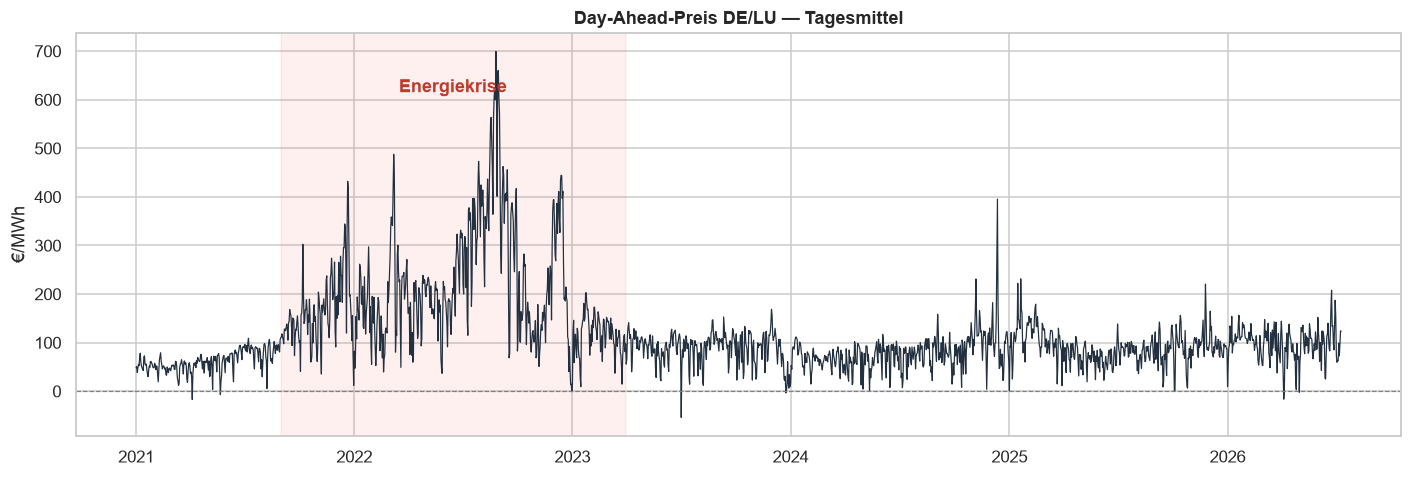

In [2]:
daily = price.resample("D").mean()
daily.index = daily.index.tz_localize(None)  # matplotlib-freundlich

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily.values, lw=0.8, color="#22303f")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.axvspan(pd.Timestamp("2021-09-01"), pd.Timestamp("2023-04-01"), color="#e74c3c", alpha=0.08)
ax.text(pd.Timestamp("2022-06-15"), daily.max()*0.88, "Energiekrise",
        color="#c0392b", ha="center", fontweight="bold")
ax.set(title="Day-Ahead-Preis DE/LU — Tagesmittel", ylabel="€/MWh", xlabel="")
plt.tight_layout(); plt.show()

## 2 · Verteilung: fette Ränder und Negativpreise

Strompreise sind **nicht normalverteilt**: eine scharfe Spitze um den Median, aber **fette
Ränder** in beide Richtungen — Knappheitsspitzen (mehrere hundert €/MWh) und **Negativpreise**
(Wind-/PV-Überschuss, den niemand abnimmt). Die **Preisdauerlinie** (Preise absteigend sortiert)
macht das plastisch; der Boxplot je Jahr zeigt, wie 2022 die ganze Verteilung nach oben schob.
→ **Kein MAPE** als Metrik (Preise kreuzen null); stattdessen MAE/RMSE in €/MWh.

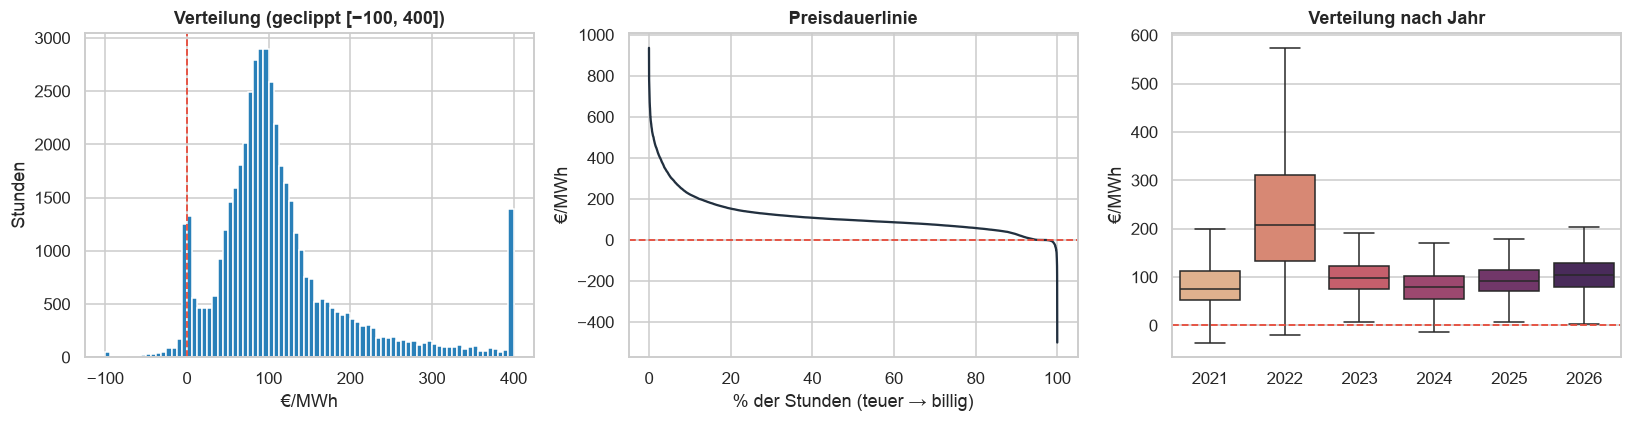

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(price.clip(-100, 400), bins=80, color="#2980b9")
axes[0].axvline(0, color="#e74c3c", lw=1.2, ls="--")
axes[0].set(title="Verteilung (geclippt [−100, 400])", xlabel="€/MWh", ylabel="Stunden")

s = np.sort(price.values)[::-1]
axes[1].plot(np.arange(len(s)) / len(s) * 100, s, color="#22303f")
axes[1].axhline(0, color="#e74c3c", lw=1.2, ls="--")
axes[1].set(title="Preisdauerlinie", xlabel="% der Stunden (teuer → billig)", ylabel="€/MWh")

by = price.to_frame("p"); by["Jahr"] = by.index.year
sns.boxplot(data=by, x="Jahr", y="p", hue="Jahr", legend=False, palette="flare",
            showfliers=False, ax=axes[2])
axes[2].axhline(0, color="#e74c3c", lw=1.2, ls="--")
axes[2].set(title="Verteilung nach Jahr", xlabel="", ylabel="€/MWh")
plt.tight_layout(); plt.show()

## 3 · Merit-Order — der ökonomische Kern

Der **Signature-Plot** des Projekts. Die Merit-Order-Theorie sagt: Der Preis wird vom *teuersten
noch benötigten* Kraftwerk gesetzt. Je höher die **Residuallast** (Last minus Wind/PV — der Teil,
den konventionelle Kraftwerke decken müssen), desto teurer das Grenzkraftwerk und desto höher der
Preis. Bei **niedriger oder negativer Residuallast** (viel EE) fällt er, bis hin zu Negativpreisen.

Jeder Punkt = eine Stunde: x = Residuallast-**Prognose**, y = Preis, Farbe = **EE-Anteil**. Die
aufsteigende Punktwolke *ist* die empirische Merit-Order-Kurve — und erklärt, warum `resload_fc_MW`
im Modell der stärkste Fundamentaltreiber ist.

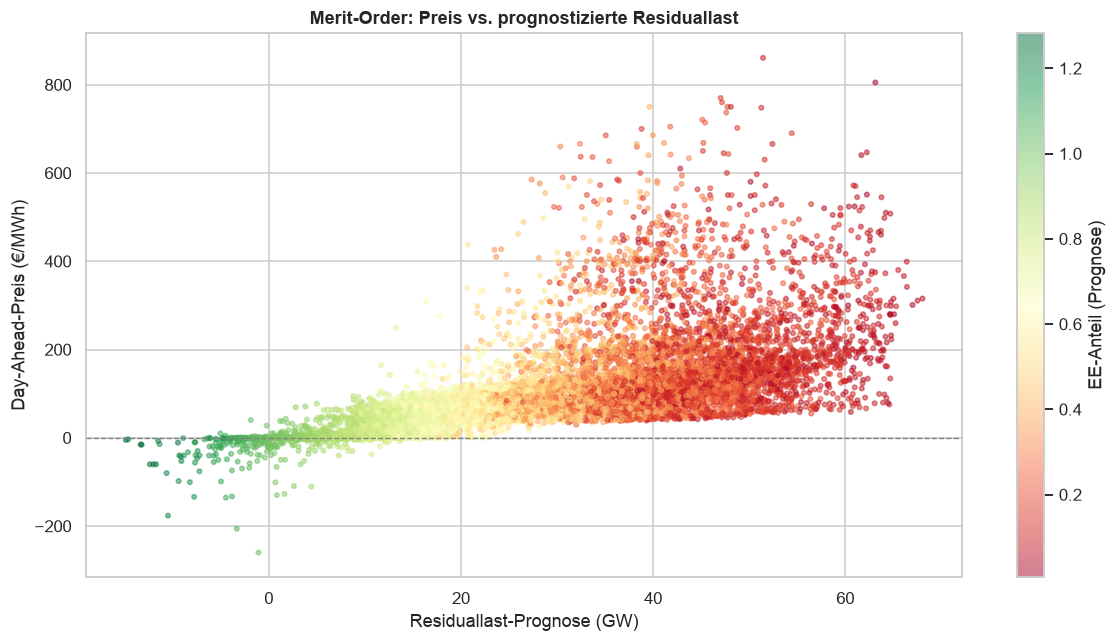

In [4]:
m = df.dropna(subset=[config.PRICE_TARGET, "resload_fc_MW", "ee_share_fc"])
samp = m.sample(min(12000, len(m)), random_state=config.SEED)

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(samp["resload_fc_MW"] / 1000, samp[config.PRICE_TARGET],
                c=samp["ee_share_fc"], cmap="RdYlGn", s=9, alpha=0.5)
ax.axhline(0, color="grey", lw=0.9, ls="--")
ax.set(title="Merit-Order: Preis vs. prognostizierte Residuallast",
       xlabel="Residuallast-Prognose (GW)", ylabel="Day-Ahead-Preis (€/MWh)")
cb = plt.colorbar(sc); cb.set_label("EE-Anteil (Prognose)")
plt.tight_layout(); plt.show()

## 4 · Negativpreise — wann kippt der Preis unter null?

Negativpreise sind **entscheidungsrelevant** (Speicher laden, flexible Lasten hochfahren) und
zugleich die **schwersten Fälle** fürs Modell. Sie werden häufiger (EE-Ausbau), konzentrieren sich
auf die **Mittagsstunden** (PV-Peak) und treten fast nur bei **hohem EE-Anteil** auf — genau die
Bedingungen, die die Merit-Order nach links/unten schieben.

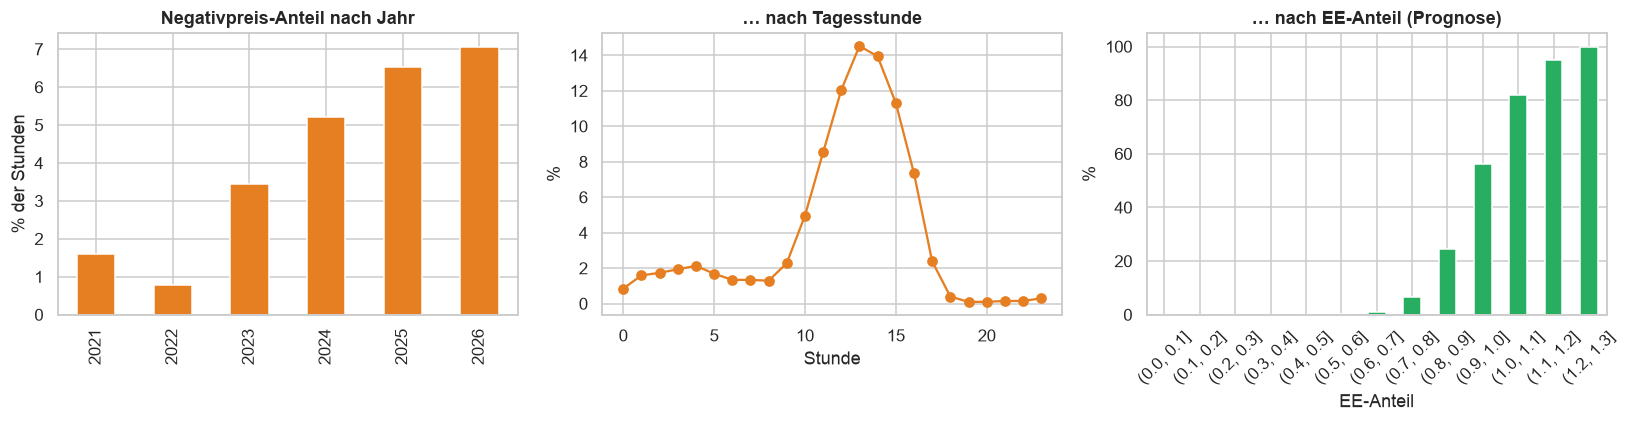

In [5]:
dp = df[df[config.PRICE_TARGET].notna()].copy()
dp["neg"] = dp[config.PRICE_TARGET] < 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
(dp.groupby(dp.index.year)["neg"].mean() * 100).plot.bar(ax=axes[0], color="#e67e22")
axes[0].set(title="Negativpreis-Anteil nach Jahr", ylabel="% der Stunden", xlabel="")

(dp.groupby(dp.index.hour)["neg"].mean() * 100).plot(ax=axes[1], marker="o", color="#e67e22")
axes[1].set(title="… nach Tagesstunde", xlabel="Stunde", ylabel="%")

dpe = dp.dropna(subset=["ee_share_fc"]).copy()
dpe["ee_bin"] = pd.cut(dpe["ee_share_fc"], np.arange(0, 1.31, 0.1))
(dpe.groupby("ee_bin", observed=True)["neg"].mean() * 100).plot.bar(ax=axes[2], color="#27ae60")
axes[2].set(title="… nach EE-Anteil (Prognose)", xlabel="EE-Anteil", ylabel="%")
axes[2].tick_params(axis="x", labelrotation=45)
plt.tight_layout(); plt.show()

## 5 · Zeitliche Muster — und der wachsende PV-Effekt

Der Preis folgt Tages- und Wochenrhythmen (Nachfrage). Besonders aufschlussreich ist die
**Veränderung über die Jahre**: Mit dem PV-Ausbau entsteht eine **Mittagsdelle** — 2021 kaum
vorhanden, ab 2024/25 deutlich (die „Duck Curve" des Preises). Die Heatmap Monat × Stunde zeigt,
wie sich die teuren Stunden saisonal verschieben. → rechtfertigt **zyklische Kalender-Features**
(Stunde, Wochentag, Monat).

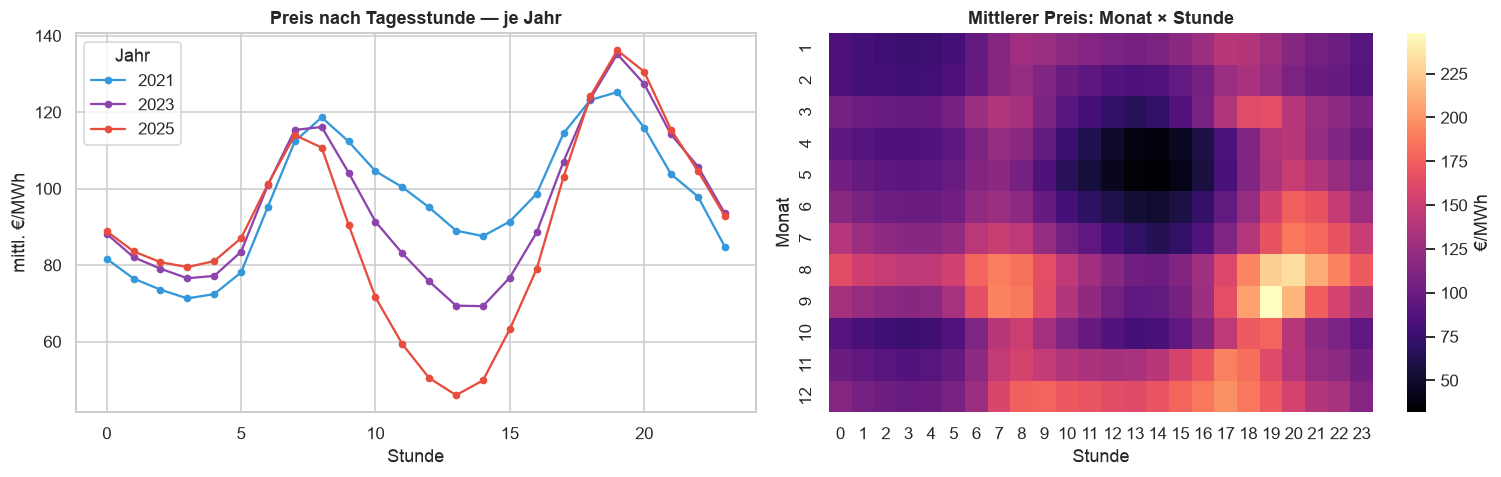

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for yr, c in zip([2021, 2023, 2025], ["#3498db", "#8e44ad", "#e74c3c"]):
    sub = price[price.index.year == yr]
    if len(sub):
        sub.groupby(sub.index.hour).mean().plot(ax=axes[0], marker="o", ms=4, label=str(yr), color=c)
axes[0].set(title="Preis nach Tagesstunde — je Jahr", xlabel="Stunde", ylabel="mittl. €/MWh")
axes[0].legend(title="Jahr")

pv = price.groupby([price.index.month, price.index.hour]).mean().unstack()
sns.heatmap(pv, cmap="magma", ax=axes[1], cbar_kws={"label": "€/MWh"})
axes[1].set(title="Mittlerer Preis: Monat × Stunde", xlabel="Stunde", ylabel="Monat")
plt.tight_layout(); plt.show()

## 6 · Zusammenhang mit den Fundamentaldaten

Die Korrelationsmatrix bestätigt die Ökonomie: Der Preis hängt **positiv an der Residuallast**
und **negativ an Wind und PV** (mehr EE → niedrigerer Preis). Die Residuallast bündelt beides und
ist der kompakteste Treiber — im Modell später eine Top-Feature-Importance.

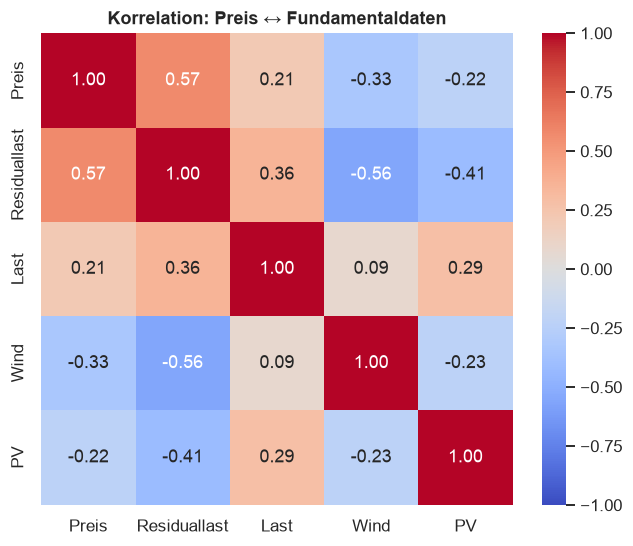

In [7]:
cols = {config.PRICE_TARGET: "Preis", "resload_fc_MW": "Residuallast", "load_fc_MW": "Last",
        "wind_fc_MW": "Wind", "pv_fc_MW": "PV"}
corr = df[list(cols)].dropna().corr()
corr.index = corr.columns = list(cols.values())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set(title="Korrelation: Preis ↔ Fundamentaldaten")
plt.tight_layout(); plt.show()

## 7 · Autokorrelation — warum Lags bei 24 h und 168 h

Die ACF zeigt klare Spitzen bei **24 h** (gleiche Stunde gestern) und **168 h** (gleiche Stunde
letzte Woche): Der Preis ähnelt sich am stärksten zu genau diesen Versätzen. Das rechtfertigt die
**Same-Hour-Lags 24/48/168** — die im Gate-Closure-Rahmen zugleich leckagefrei sind (sie fallen
auf komplett geräumte Vortage).

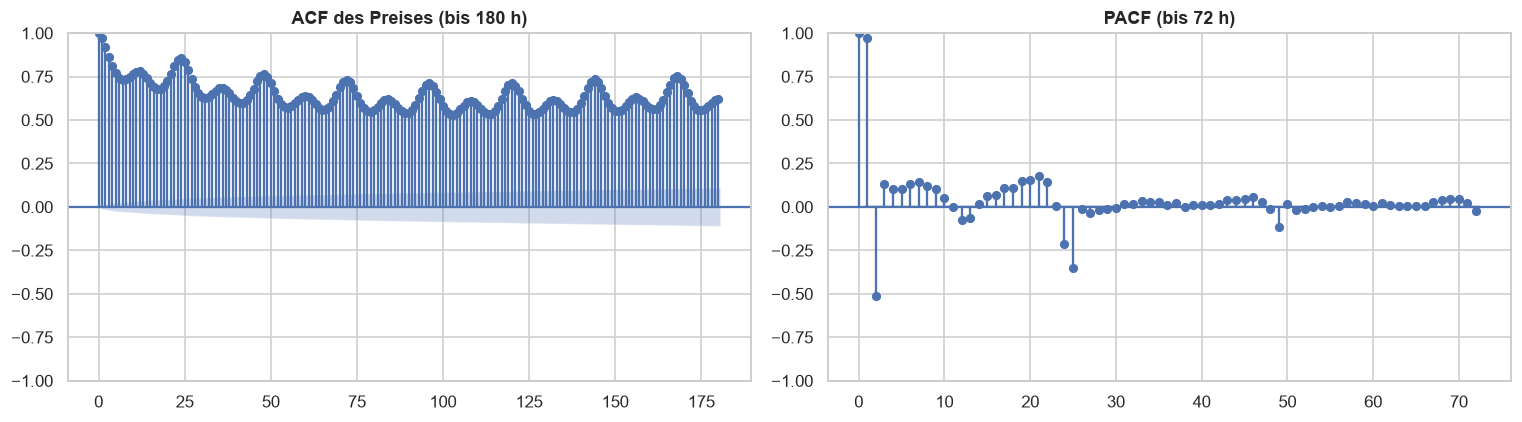

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(price, lags=180, ax=axes[0]); axes[0].set(title="ACF des Preises (bis 180 h)")
plot_pacf(price, lags=72, ax=axes[1], method="ywm"); axes[1].set(title="PACF (bis 72 h)")
plt.tight_layout(); plt.show()

## 8 · Fazit für die Modellierung

- **Residuallast-Prognose = Haupttreiber** (Merit-Order): der wichtigste Fundamental-Feature.
- **Wind- und PV-Prognose** zusätzlich (drücken den Preis, treiben Negativpreise).
- **Preis-Lags 24/48/168 + Vortags-Aggregate**: kodieren das Brennstoffkosten-**Niveau/Regime**
  (bewusster Proxy für Gas-/CO₂-Preise) — und sind im Gate-Closure-Rahmen leckagefrei.
- **Zyklische Kalender-Features** (Stunde/Wochentag/Monat + Feiertage): Tages-/Wochen-/Saisonmuster.
- **Regimewechsel (2022)** → **rolling-origin**-Backtest statt Zufalls-Split; Metriken pro Jahr.
- **Negativpreise** als eigene Auswertungs-Lens (Precision/Recall), nicht wegglätten.

→ Genau diese Bausteine setzt `04_price_model` um.